<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install textstat

In [9]:
import pandas as pd
import numpy as np
import re
import torch
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import textstat




# Data Preparation & Preprocessing


In [10]:
def preprocess_isot(df, is_fake):

  df = df.dropna(subset=['text'])

  df['text'] = df['text'].astype(str)

  def clean_text(text):
    if not is_fake:
      text = re.sub(r'^.*?\(Reuters\)\s*-\s*', '', text)
    return text.strip()

  df['text'] = df['text'].apply(clean_text)

  return df[df['text'].str.strip() != ""]

print("Loading and cleaning ISOT dataset...")
true_df = pd.read_csv("True.csv", quoting=3, on_bad_lines='skip')
fake_df = pd.read_csv("Fake.csv", quoting=3, on_bad_lines='skip')

true_df = preprocess_isot(true_df, is_fake=False)
fake_df = preprocess_isot(fake_df, is_fake=True)

true_df['label'] = 0
fake_df['label'] = 1

df = pd.concat([true_df, fake_df]).sample(frac=1, random_state=42).reset_index(drop=True)



Loading and cleaning ISOT dataset...


/tmp/ipykernel_9136/352110526.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].astype(str)
/tmp/ipykernel_9136/352110526.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].apply(clean_text)
/tmp/ipykernel_9136/352110526.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

# Feature Engineering

In [11]:
def extract_linguistic_features(texts):
  features = []
  for text in texts:
    features.append([
        textstat.flesch_reading_ease(text),
        textstat.smog_index(text),
        len(text.split()),
        text.count('!'),
        sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0
    ])
  return np.array(features)

print("Extracting engineered linguistic features...")
ling_features = extract_linguistic_features(df['text'])

X_train_text, X_test_text, y_train, y_test, X_train_ling, X_test_ling = train_test_split(
    df['text'], df['label'], ling_features, test_size=0.2, random_state=42, stratify=df['label']
)

Extracting engineered linguistic features...


# Baseline

In [12]:
print("Training XGBoost Baseline...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

X_train_xgb = np.hstack((X_train_tfidf, X_train_ling))
X_test_xgb = np.hstack((X_test_tfidf, X_test_ling))

xgb_model = XGBClassifier(n_estimators=100, learning_rate = 0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_xgb, y_train)


Training XGBoost Baseline...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

# Advanced: RoBERTa Fine-tuning

In [13]:
print("Fine-tuning RoBERTa (Transfer Learning)...")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class FakeNewsDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len=256):
    self.encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=max_len)
    self.labels = labels.tolist()

  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

train_dataset = FakeNewsDataset(X_train_text, y_train, tokenizer)
test_dataset = FakeNewsDataset(X_test_text, y_test, tokenizer)

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    weight_decay=0.01,
)

trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

Fine-tuning RoBERTa (Transfer Learning)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,0.220007
2,No log,0.123481


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=142, training_loss=0.335907197334397, metrics={'train_runtime': 63.0557, 'train_samples_per_second': 17.857, 'train_steps_per_second': 2.252, 'total_flos': 148131524167680.0, 'train_loss': 0.335907197334397, 'epoch': 2.0})

# Hybrid Ensemble

In [14]:
print("Implementing Hybrid Ensemble...")
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
roberta_raw = trainer.predict(test_dataset)
roberta_probs = torch.nn.functional.softmax(torch.tensor(roberta_raw.predictions), dim=1)[:, 1].numpy()

hybrid_probs = (xgb_probs + roberta_probs) / 2
y_pred_hybrid = (hybrid_probs > 0.5).astype(int)



Implementing Hybrid Ensemble...


# Evaluation & XAI (SHAP)

Final Results (Hybrid): 
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.94      1.00      0.97        98

    accuracy                           0.96       141
   macro avg       0.97      0.93      0.95       141
weighted avg       0.96      0.96      0.96       141

Generating SHAP feautre importance...


/tmp/ipykernel_9136/1675369038.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_xgb[:100], feature_names=list(tfidf.get_feature_names_out()) + ['Ease', 'SMOG', 'Words', '!', 'Caps'])


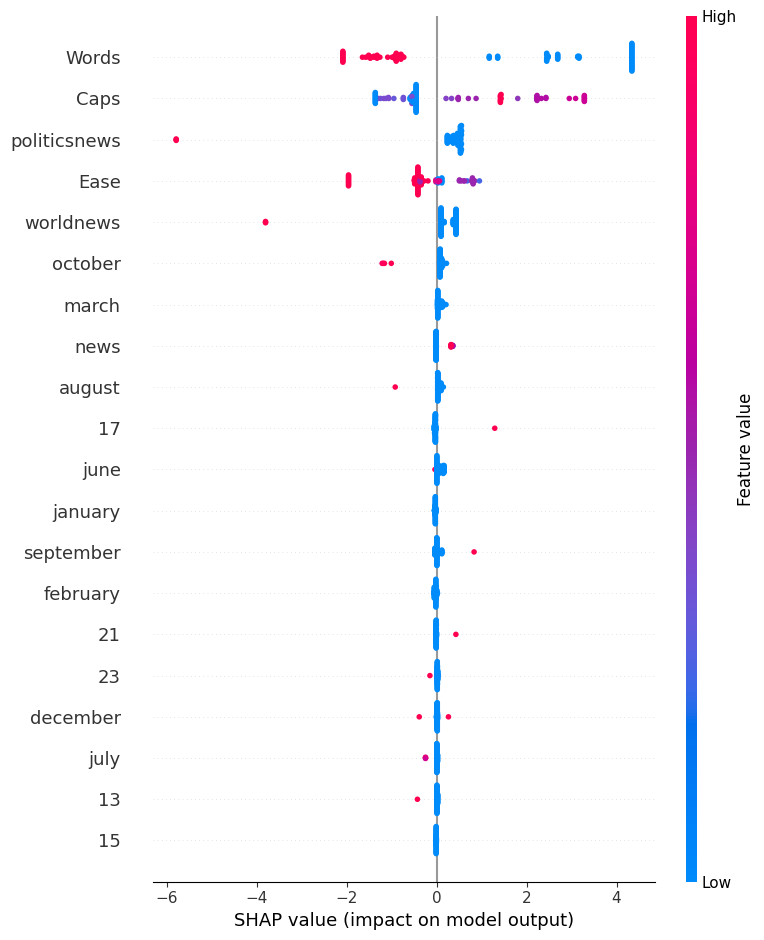

In [15]:
print("Final Results (Hybrid): ")
print(classification_report(y_test, y_pred_hybrid))

print("Generating SHAP feautre importance...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb[:100])
shap.summary_plot(shap_values, X_test_xgb[:100], feature_names=list(tfidf.get_feature_names_out()) + ['Ease', 'SMOG', 'Words', '!', 'Caps'])
